In [ ]:
!pip install torch
!pip install huggingface_hub
!pip install evaluate
!pip install datasets
!pip install transformers triton>=3.4 kernels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.7 MB/s eta 0:00:00


# creating 3 dataset, including human, gpt3.5 and gpt5.4 dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

from huggingface_hub import login
from google.colab import userdata

# This pulls the token directly from my Secrets manager
hf_token = userdata.get('HF_TOKEN')
login(hf_token)

In [3]:
# download all of the necessary dataset into pandas dataframe
import pandas as pd
full_HC3 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLU_project/HC3_dataset/full_preprocessed_data.csv")
gpt5_len = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLU_project/GPT5.4-mini-data/new_full_data.csv")

In [4]:
all_human = full_HC3[full_HC3["label"] == 0]['text']
all_gpt3 = full_HC3[full_HC3["label"] == 1]['text']
all_gpt5 = gpt5_len['gpt_5_4_mini']

# computing length analysis

In [5]:
# download necessary library and resource
from nltk.lm import Vocabulary
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
# computing length, vocabulary size, and density fro gpt3.5 dataset
sum_length = 0
i = 0
full_length_gpt3 = []
tokenized_list = []
for text in list(all_gpt3):
  tokenized = nltk.tokenize.word_tokenize(str(text))
  i = i+1
  full_length_gpt3.append(len(tokenized))
  tokenized_list.extend(tokenized)
  sum_length += len(tokenized)
vocab_size = len(Vocabulary(tokenized_list))
print("average of text length = ", sum_length/i)
print("total vocabulary = ", vocab_size)
print("density = ", 100 * vocab_size/(sum_length))

average of text length =  193.62170853510895
total vocabulary =  73099
density =  1.428326066877447


In [12]:
# computing length, vocabulary size, and density fro human dataset
sum_length = 0
i = 0
full_length_human = []
tokenized_list = []
for text in list(all_human):
  tokenized = nltk.tokenize.word_tokenize(str(text))
  i = i+1
  tokenized_list.extend(tokenized)
  full_length_human.append(len(tokenized))
  sum_length += len(tokenized)
vocab_size = len(Vocabulary(tokenized_list))
print("average of text length = ", sum_length/i)
print("total vocabulary = ", vocab_size)
print("density = ", 100 * vocab_size/(sum_length))

average of text length =  137.42958885194673
total vocabulary =  111196
density =  1.4700178285733625


In [13]:
# # computing length, vocabulary size, and density fro gpt5.4-mini dataset
sum_length = 0
i = 0
full_length_gpt5 = []
tokenized_list = []
for text in list(all_gpt5):
  tokenized = nltk.tokenize.word_tokenize(str(text))
  i = i+1
  full_length_gpt5.append(len(tokenized))
  tokenized_list.extend(tokenized)
  sum_length += len(tokenized)
vocab_size = len(Vocabulary(tokenized_list))
print("average of text length = ", sum_length/i)
print("total vocabulary = ", vocab_size)
print("density = ", 100 * vocab_size/(sum_length))

average of text length =  126.73861195885611
total vocabulary =  54395
density =  0.8085423213451457


In [9]:
# padding to max length for future graph
# the result into one pandas dataframe
import numpy as np
lists = [full_length_human, full_length_gpt3, full_length_gpt5]
max_len = max(len(l) for l in lists)
padded = [l + [0] * (max_len - len(l)) for l in lists]
result = np.vstack(padded)
result_1 = result[0]
result_2 = result[1]
result_3 = result[2]
col_stack = np.stack((result_1, result_2, result_3), axis=-1)
df = pd.DataFrame(col_stack, columns=["full_human", "full_gpt3", "full_gpt5"])

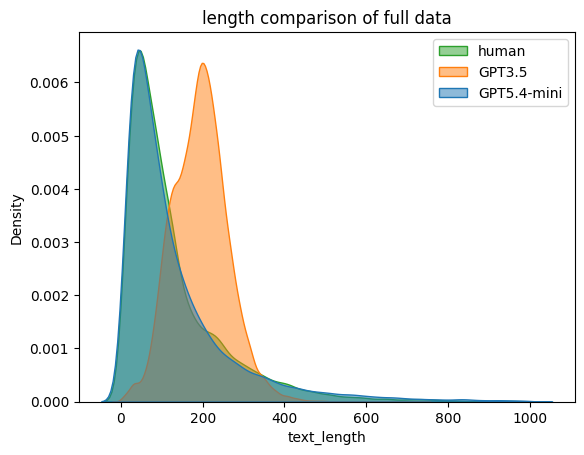

In [14]:
# making KDE density graph
import seaborn as sns
import matplotlib.pyplot as plt
# for removing the effects of paading values and distinct numbers
df = df[(df != 0).all(axis=1)]
df = df[(df <= 1000).all(axis=1)]
sns.kdeplot(data=df, common_norm=False, fill=True, alpha=0.5)
plt.title("length comparison of full data")
plt.xlabel("text_length")
plt.legend(["human", "GPT3.5", "GPT5.4-mini"])

# computing the perplexity of each sentences and texts

In [ ]:
# install model and tokenizer to compute perplexity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import os
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
model_name = 'openai-community/gpt2'
# because max_token is twice as much as that of roBerta tokenizer
max_token = 1024

# prepareing tokenizer and model.
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

#because old tokenizer don't have pad_token default, adding it
tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Download the sentence segmentation tokenizer
import nltk
from nltk.tokenize import sent_tokenize

# Download the necessary model data
nltk.download('punkt_tab')

text = "Hello! This is NLTK. It's great for NLP, isn't it? Dr. Smith says so."
sentences = sent_tokenize(text)
print(sentences)

['Hello!', 'This is NLTK.', "It's great for NLP, isn't it?", 'Dr. Smith says so.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# ppl computation for text, sent ppl
# from https://gist.github.com/Kartikaggarwal98/81d4ca2e0c5d27ab9f72c7404cf73e6b
import torch
import math
import nltk
from nltk.tokenize import sent_tokenize

# Necessary resource for sentence segmentation
nltk.download('punkt_tab')

# text ppl lists
text_ppl_full_human = []
text_ppl_full_gpt3 = []
text_ppl_full_gpt5 = []

# sent ppl lists
sent_ppl_full_human = []
sent_ppl_full_gpt3 = []
sent_ppl_full_gpt5 = []

# scoring function of sentences for perplexity
def score(sentence, tokenizer, model):
    with torch.no_grad():
      tokenize_input = tokenizer.tokenize(sentence)
      tensor_input = torch.tensor([tokenizer.convert_tokens_to_ids(tokenize_input[:max_token])]).to(device)
      out=model(tensor_input, labels=tensor_input)

    return math.exp(out.loss.item())

# for human data
for data in all_human.values:
  text_ppl_full_human.append(score(data, model=model, tokenizer = tokenizer))
  sentences = sent_tokenize(data)
  for sent in sentences:
    sent_ppl_full_human.append(score(sent, model=model, tokenizer = tokenizer))
print("finish 1")

# for gpt3.5 data
for data in all_gpt3.values:
  text_ppl_full_gpt3.append(score(data, model=model, tokenizer = tokenizer))
  sentences = sent_tokenize(data)
  for sent in sentences:
    sent_ppl_full_gpt3.append(score(sent, model=model, tokenizer = tokenizer))
print("finish 2")

# for gpt5.4-mini data
for data in all_gpt5.values:
  text_ppl_full_gpt5.append(score(data, model=model, tokenizer = tokenizer))
  sentences = sent_tokenize(data)
  for sent in sentences:
    text_ppl_full_gpt5.append(score(sent, model=model, tokenizer = tokenizer))
print("finish 3")
print("All PPL computations finished!")

In [ ]:
# padding to max length and creating one np array that has the same length
import numpy as np
lists = [text_ppl_full_human, sent_ppl_full_human, text_ppl_full_gpt3, sent_ppl_full_gpt3,text_ppl_full_gpt5, sent_ppl_full_gpt5]
max_len = max(len(l) for l in lists)
padded = [l + [0] * (max_len - len(l)) for l in lists]
result = np.vstack(padded)
result_1 = result[0]
result_2 = result[1]
result_3 = result[2]
result_4 = result[3]
result_5 = result[4]
result_6 = result[5]

col_stack = np.stack((result_1, result_2, result_3, result_4, result_5, result_6), axis=-1)

In [ ]:
# creating pandas dataframe and store it for future use
df = pd.DataFrame(col_stack, columns=["text_ppl_full_human", "sent_ppl_full_human", "text_ppl_full_gpt3", "sent_ppl_full_gpt3", "text_ppl_full_gpt5", "sent_ppl_full_gpt5"])
df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLU_project/PPL/ppl_new_gpt_2.csv")

# change the output graph into Log-Scaled Density Plot(KDE)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
df_gpt_2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLU_project/PPL/ppl_new_gpt_2.csv")

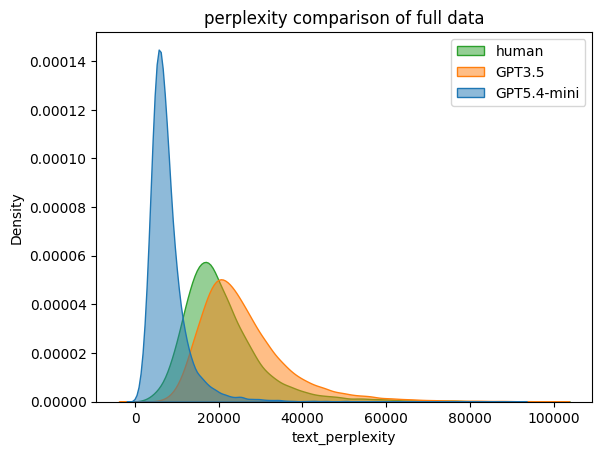

In [18]:
# same as the length KDE graph code
df = df_gpt_2[["text_ppl_full_human", "text_ppl_full_gpt3","text_ppl_full_gpt5"]]
df = df[(df != 0).all(axis=1)]
df = df[(df <= 100000).all(axis=1)]
sns.kdeplot(data=df, common_norm=False, fill=True, alpha=0.5)
plt.title("perplexity comparison of full data")
plt.xlabel("text_perplexity")
plt.legend(["human", "GPT3.5", "GPT5.4-mini"])

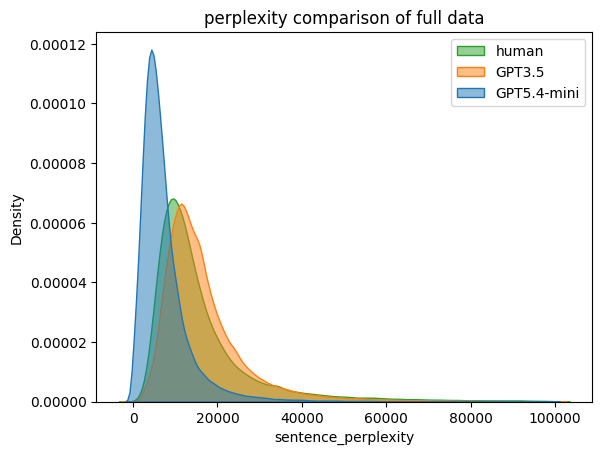

In [19]:
df = df_gpt_2[["sent_ppl_full_human", "sent_ppl_full_gpt3", "sent_ppl_full_gpt5"]]
df = df[(df != 0).all(axis=1)]
df = df[(df <= 100000).all(axis=1)]
sns.kdeplot(data=df, common_norm=False, fill=True, alpha=0.5)
plt.title("perplexity comparison of full data")
plt.xlabel("sentence_perplexity")
plt.legend(["human", "GPT3.5", "GPT5.4-mini"])